In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import geopy
import plotly.express as px
import ast
import json
from pd_replicator import replicator
from datetime import datetime
import gc
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('mode.use_inf_as_na', True)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
sns.set_style("whitegrid")
sns.set(rc={'figure.figsize':(10,6)})

/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_39336/3665024186.py:14: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.set_option('mode.use_inf_as_na', True)


# 1. Data Loading and Inspection

In [3]:
heart_disease = pd.read_csv("../data/q1_heart_disease.csv")

In [9]:
df = heart_disease

In [10]:
df.shape

(800, 12)

In [11]:
df.dtypes

age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

In [13]:
df.isnull().sum()

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

In [14]:
df.head(5)

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.00,399.00,0,left_ventricular_hypertrophy,169,0,0.40,up,1
1,58,1,non_anginal,163.00,310.00,1,st_t_wave_abnormality,121,1,1.10,up,1
2,44,1,non_anginal,128.00,175.00,0,normal,183,1,0.20,up,0
3,72,1,asymptomatic,114.00,177.00,0,st_t_wave_abnormality,150,0,1.00,up,1
4,37,1,non_anginal,149.00,271.00,0,normal,136,0,0.40,flat,0


# 2. Exploratory Data Analysis 

## Target Class Distribution

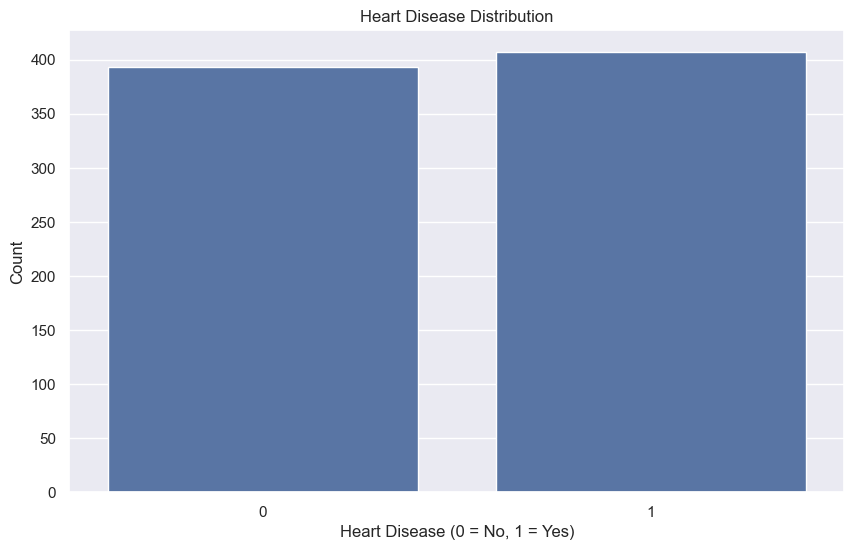

In [19]:
plt.figure()
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

**Interpretation:**

The distribution of the target variable shows that the dataset is fairly balanced, with a slightly higher number of patients having heart disease (class 1) compared to those without (class 0).

This suggests that class imbalance is not a major concern, and standard classification models can be applied without significant bias toward one class.

## Correlation heatmap

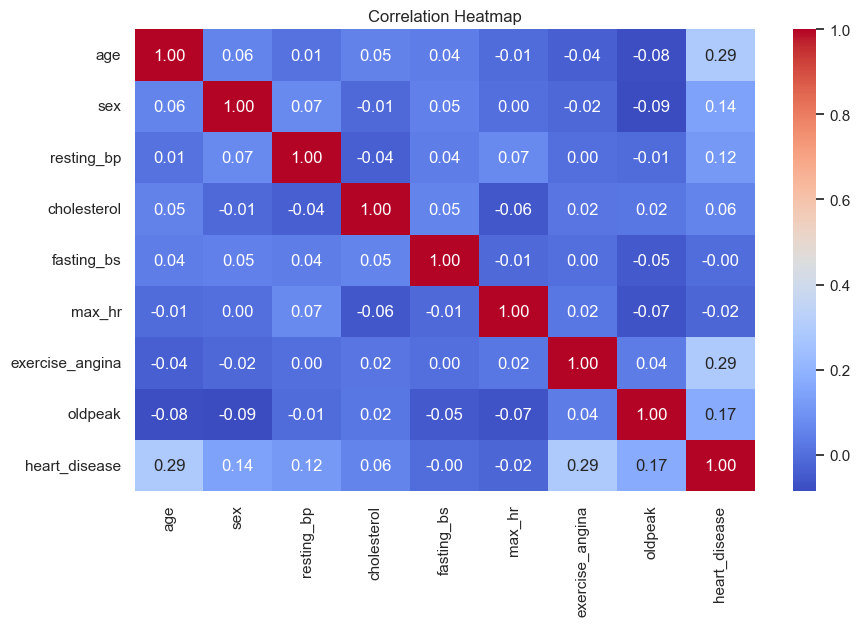

In [21]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Interpretation:**

The correlation heatmap shows that most features have relatively low correlation with each other, indicating limited multicollinearity.

In relation to the target variable (heart_disease), the strongest positive correlations are observed with:
- age (~0.29)
- exercise_angina (~0.29)
- oldpeak (~0.17)

This suggests that older age, presence of exercise-induced angina, and higher ST depression (oldpeak) are associated with a higher likelihood of heart disease.

Other features such as cholesterol and fasting blood sugar show very weak correlations with the target, indicating they may have limited predictive power individually.

## Age vs Heart Disease Interpretation

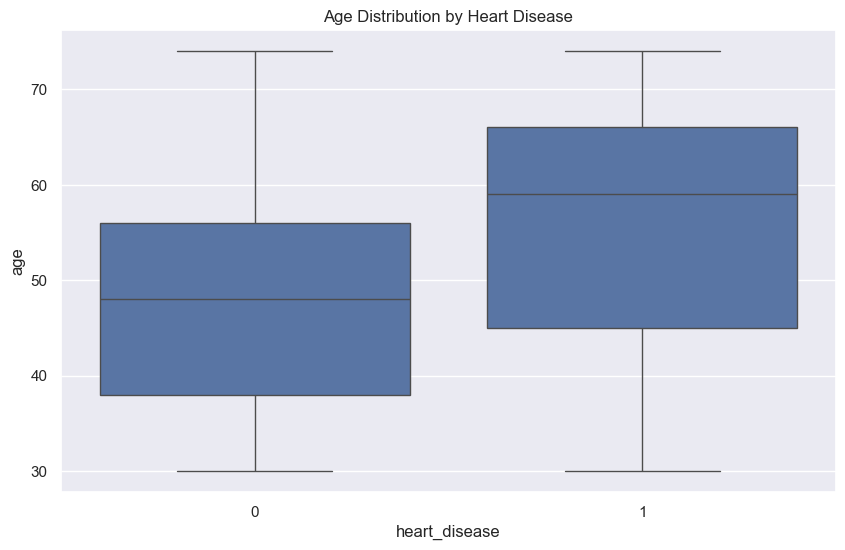

In [22]:
plt.figure()
sns.boxplot(x='heart_disease', y='age', data=df)
plt.title("Age Distribution by Heart Disease")
plt.show()

**Interpretation:**

The boxplot shows that patients with heart disease tend to be older compared to those without the condition.

The median age for individuals with heart disease is higher, and the distribution is shifted toward older age groups. This indicates that age is an important factor in predicting heart disease risk.

However, there is still overlap between the two groups, suggesting that age alone is not sufficient for classification and must be combined with other features.

## Chest Pain Type vs Heart Disease

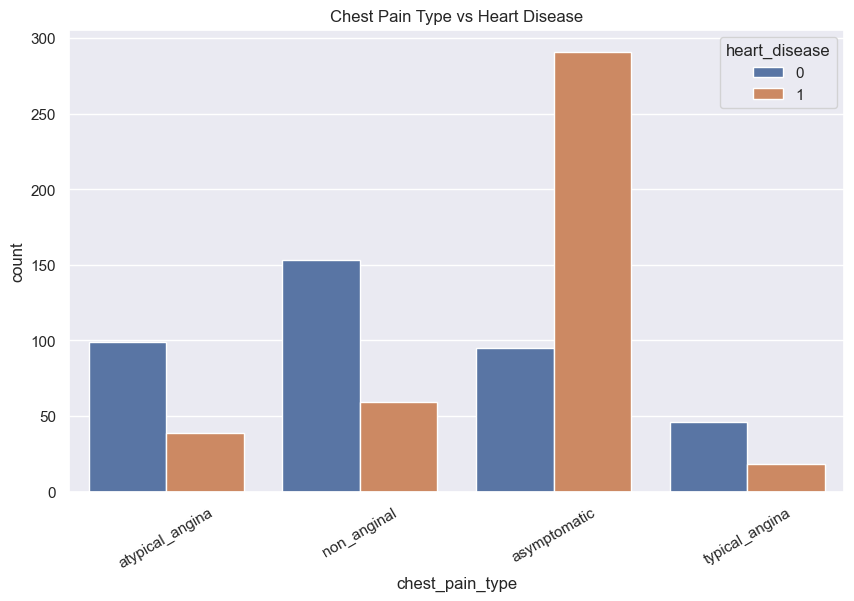

In [29]:
plt.figure()
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.xticks(rotation=30)
plt.show()

**Interpretation:**


The distribution shows a clear variation in heart disease prevalence across different chest pain types.

Patients with asymptomatic chest pain have a significantly higher proportion of heart disease cases compared to other categories. In contrast, typical angina and atypical angina are more commonly associated with the absence of heart disease.

This indicates that chest pain type is a highly informative feature, with asymptomatic cases being strongly linked to the presence of heart disease. Therefore, this variable is likely to be a key predictor in the model.

Although it appears counterintuitive, asymptomatic patients show a higher prevalence of heart disease. This may be because heart disease can often be silent, while typical chest pain symptoms can arise from non-cardiac causes. This highlights the importance of not relying solely on symptoms for diagnosis.

# 3. Data Preprocessing

In [40]:
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

In [41]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index(['chest_pain_type', 'resting_ecg', 'st_slope'], dtype='object')
Numerical: Index(['age', 'sex', 'resting_bp', 'cholesterol', 'fasting_bs', 'max_hr',
       'exercise_angina', 'oldpeak'],
      dtype='object')


### Handling missing values

In [42]:
# Fill numerical with median
for col in numerical_cols:
    X[col].fillna(X[col].median(), inplace=True)

# Fill categorical with mode
for col in categorical_cols:
    X[col].fillna(X[col].mode()[0], inplace=True)

/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_39336/2487135730.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(X[col].median(), inplace=True)
/var/folders/g7/fm1k83t55yx3c4mjj3qk9sxr0000gn/T/ipykernel_39336/2487135730.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

**Justification:**

Missing values were handled using imputation rather than row deletion.

Row deletion was avoided because it can lead to loss of valuable data, especially when the dataset size is limited, and may introduce bias if missing values are not randomly distributed.

For numerical features, median imputation was used as it is robust to outliers and preserves the distribution of the data better than mean imputation.

For categorical features, missing values were filled using the mode (most frequent category), ensuring that the most representative category is used.

This approach retains all observations while minimizing distortion in the data.

### One-hot encoding for categorical variables

In [43]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

### Split data into train and test dataset

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

### Scale numerical features

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# 4. Model Training

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

### Decision Tree Classifier

In [47]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Random Forest Classifier

In [48]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Gradient Boosting Classifier

In [49]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [50]:
dt_preds = dt_model.predict(X_test)
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)

Three models were trained to compare performance across different approaches.

A Decision Tree was used as a simple baseline model. A Random Forest was used to improve performance by combining multiple trees and reducing overfitting. A Gradient Boosting model was used as a more advanced method that builds trees sequentially to correct previous errors.

The parameter random_state=42 was set for all models to ensure reproducibility of results.

# 5. Model Evaluation

In [51]:
from sklearn.metrics import confusion_matrix, classification_report

In [52]:
print("Decision Tree Confusion Matrix:")
print(confusion_matrix(y_test, dt_preds))

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_preds))

Decision Tree Confusion Matrix:
[[57 22]
 [25 56]]

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



In [53]:
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Confusion Matrix:
[[61 18]
 [15 66]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [54]:
print("Gradient Boosting Confusion Matrix:")
print(confusion_matrix(y_test, gb_preds))

print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gb_preds))

Gradient Boosting Confusion Matrix:
[[61 18]
 [19 62]]

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



**Conclusion:**

Among the three models, the Random Forest classifier performs the best overall.

Although all models achieve comparable accuracy, Random Forest stands out with the highest F1-score for the heart disease class (1), indicating the best balance between precision and recall.

More importantly, Random Forest achieves the highest recall (0.81) for class 1, meaning it correctly identifies the largest proportion of patients with heart disease. This is critical in a healthcare context, where false negatives (missed disease cases) are more severe than false positives.

The Decision Tree model performs the weakest, with lower recall and F1-score, suggesting poorer generalization and a higher likelihood of overfitting.

Gradient Boosting performs better than Decision Tree but does not match Random Forest in terms of recall and overall F1-score.

Therefore, Random Forest is the preferred model, as it delivers the most reliable performance across key evaluation metrics, particularly in correctly identifying heart disease cases.

# 6. Hyperparameter Tuning

In [56]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [57]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

In [58]:
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # important: aligns with your evaluation
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 5, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [63]:
#Report the best parameters found
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [64]:
best_rf = grid_search.best_estimator_

tuned_preds = best_rf.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print("Tuned Model Confusion Matrix:")
print(confusion_matrix(y_test, tuned_preds))

print("\nTuned Model Classification Report:")
print(classification_report(y_test, tuned_preds))

Tuned Model Confusion Matrix:
[[57 22]
 [15 66]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("Baseline RF:")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1:", f1_score(y_test, rf_preds))

print("\nTuned RF:")
print("Accuracy:", accuracy_score(y_test, tuned_preds))
print("Recall:", recall_score(y_test, tuned_preds))
print("F1:", f1_score(y_test, tuned_preds))

Baseline RF:
Accuracy: 0.79375
Recall: 0.8148148148148148
F1: 0.8

Tuned RF:
Accuracy: 0.76875
Recall: 0.8148148148148148
F1: 0.7810650887573964


**Hyperparameter Tuning:**

GridSearchCV was used to tune key hyperparameters of the Random Forest model, including the number of estimators, maximum depth, and minimum samples required for splitting.

The best parameters found were:
- n_estimators = 200
- max_depth = None
- min_samples_split = 5

After tuning, the model was evaluated on the test set and compared with the baseline Random Forest model.

The tuned model achieved the same recall (0.81) for the heart disease class, indicating that it maintains the ability to correctly identify patients with the condition. However, overall performance slightly decreased, with lower accuracy (0.77 vs 0.79) and a reduced F1-score (0.78 vs 0.80).

This occurred because tuning introduced a trade-off: while the model continued to identify the same number of true positive cases, it also produced more false positives, reducing precision and overall F1-score.

Additionally, the baseline Random Forest model was already performing near optimally, leaving limited room for improvement. As a result, hyperparameter tuning did not lead to better performance in this case.

Therefore, the baseline Random Forest model remains the preferred choice, as it provides better overall performance while maintaining high recall.